# 02 — Feature Engineering

Per-event features for the South Asia earthquake catalog (M ≥ 3.5, 1973–present).

Built from `data/processed/catalog.parquet` (produced by `src.fetch_usgs`); writes
`data/processed/features.parquet` (produced by `src.features`).

The headline plots are the **log10(η) bimodal histogram** and the **2-D (log T, log R)
lobes** — together they are the central evidence for a cluster-vs-background split
in the catalog.

See [PROJECT_PROPOSAL.md](../PROJECT_PROPOSAL.md) sections 7 (Phase C) and 9.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))
FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context="notebook", style="whitegrid")
print("OK")

OK


## Load the feature table

In [2]:
df = pd.read_parquet(PROJECT_ROOT / "data" / "processed" / "features.parquet")
print(f"{len(df):,} events × {df.shape[1]} columns")
df[["time", "mag", "depth", "dt_prev", "d_prev_km", "log10_eta",
    "local_density_30d", "bath_residual"]].head(10)

12,866 events × 30 columns


,time,mag,depth,dt_prev,d_prev_km,log10_eta,local_density_30d,bath_residual
0,1973-01-02 16:25:36+00:00,4.8,137.0,NaN,NaN,NaN,0,NaN
1,1973-01-10 03:02:32.100000+00:00,4.8,18.0,7.442316,470.333951,-2.215032,0,NaN
2,1973-01-10 21:07:45.600000+00:00,4.3,110.0,0.753628,466.349547,-4.002993,1,-0.7
3,1973-01-12 23:39:25.900000+00:00,5.2,126.0,2.105328,43.791373,-3.913049,1,-2.1
4,1973-01-13 14:14:41.100000+00:00,5.0,50.0,0.607815,1321.221687,-2.985258,0,NaN
5,1973-01-14 11:39:25.100000+00:00,4.0,90.0,0.892176,1378.155244,-3.199345,0,NaN
6,1973-01-15 18:48:43.600000+00:00,3.8,33.0,1.298131,390.872765,-3.477700,0,NaN
7,1973-01-15 23:20:47+00:00,3.9,151.0,0.188928,354.815971,-3.991981,0,NaN
8,1973-01-16 21:31:26+00:00,5.1,42.0,0.924062,676.859279,-3.528763,1,-2.3
9,1973-01-18 11:08:11.800000+00:00,4.8,34.0,1.567197,686.919521,-4.497130,1,-1.2


## Magnitude distribution and Gutenberg–Richter fit

The Gutenberg–Richter law predicts log10 N(≥M) decreases linearly with M, slope −b.
For tectonic earthquakes b ≈ 1; this catalog should land in [0.8, 1.2].

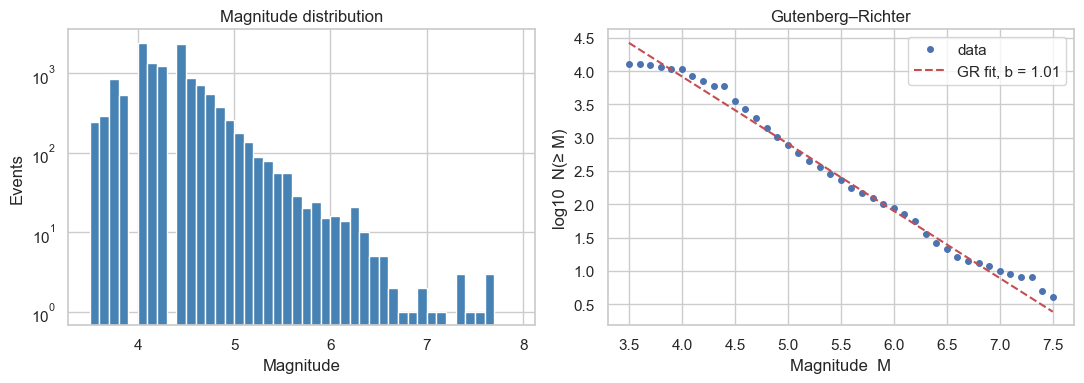

b-value = 1.01  (expected ≈ 1.0)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(df["mag"], bins=np.arange(3.5, 8.0, 0.1), color="steelblue", edgecolor="white")
axes[0].set(xlabel="Magnitude", ylabel="Events", title="Magnitude distribution")
axes[0].set_yscale("log")

m_bins = np.arange(3.5, 7.6, 0.1)
N_ge_M = np.array([(df["mag"] >= m).sum() for m in m_bins], dtype=float)
mask = N_ge_M > 10
slope, intercept = np.polyfit(m_bins[mask], np.log10(N_ge_M[mask]), 1)
b_value = -slope
axes[1].plot(m_bins, np.log10(np.maximum(N_ge_M, 1)), "o", ms=4, label="data")
axes[1].plot(m_bins, slope * m_bins + intercept, "r--", label=f"GR fit, b = {b_value:.2f}")
axes[1].set(xlabel="Magnitude  M", ylabel="log10  N(≥ M)", title="Gutenberg–Richter")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "02_mag_gr.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"b-value = {b_value:.2f}  (expected ≈ 1.0)")

## Inter-event gaps

Heavy-tailed distributions are the catalog-level signature of clustering: most pairs
of consecutive events are seconds-to-hours apart (in-cluster), with a long tail of
days-to-weeks gaps (between clusters).

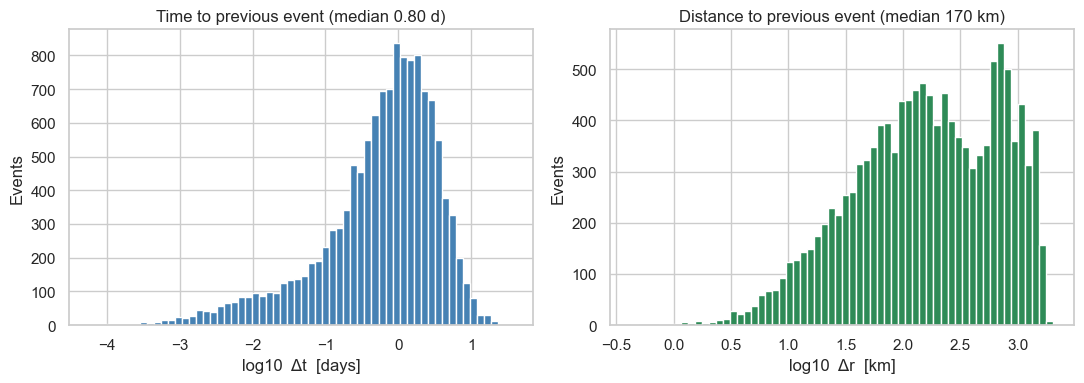

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(np.log10(df["dt_prev"].dropna()), bins=60, color="steelblue", edgecolor="white")
axes[0].set(xlabel="log10  Δt  [days]", ylabel="Events",
            title=f"Time to previous event (median {df['dt_prev'].median():.2f} d)")

axes[1].hist(np.log10(df["d_prev_km"].clip(lower=1e-2).dropna()), bins=60,
             color="seagreen", edgecolor="white")
axes[1].set(xlabel="log10  Δr  [km]", ylabel="Events",
            title=f"Distance to previous event (median {df['d_prev_km'].median():.0f} km)")

plt.tight_layout()
plt.savefig(FIG_DIR / "02_gaps.png", dpi=120, bbox_inches="tight")
plt.show()

## Zaliapin η — the bimodal feature

For each event j, the nearest-neighbour distance is

$$\eta_j = \min_i \, T_{ij} \cdot R_{ij}, \qquad
  T_{ij} = (t_j - t_i)\, 10^{-qbM_i}, \quad
  R_{ij} = r_{ij}^{\,d}\, 10^{-(1-q)bM_i}$$

with defaults b = 1.0, d = 1.6, q = 0.5 (Zaliapin & Ben-Zion 2008).

The expected shape: a **clustered lobe** at low η (events triggered by a recent,
nearby, comparable-size event) and a **background lobe** at high η. The saddle between
them is the natural cluster/background threshold.

Clustered events:   929  (7.2%)
Background events: 11936  (92.8%)


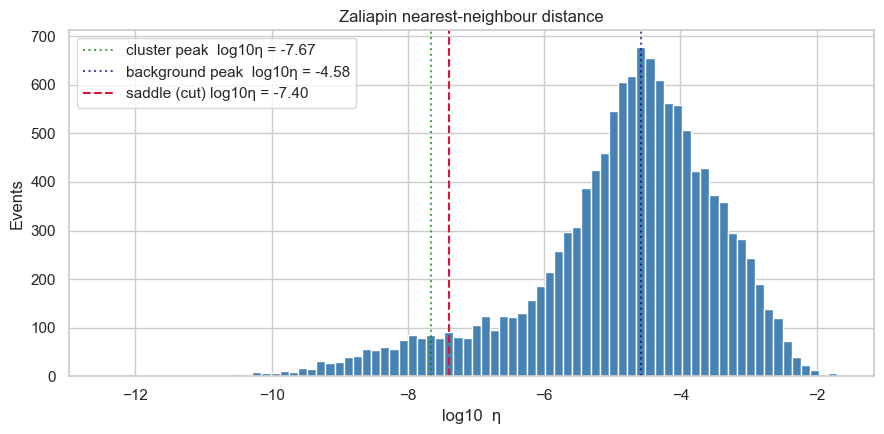

In [5]:
le = df["log10_eta"].dropna()

fig, ax = plt.subplots(figsize=(9, 4.5))
counts, edges, _ = ax.hist(le, bins=80, color="steelblue", edgecolor="white")
centers = 0.5 * (edges[:-1] + edges[1:])
smoothed = np.convolve(counts, [0.2] * 5, mode="same")

peaks = [i for i in range(2, len(smoothed) - 2)
         if smoothed[i] > smoothed[i-1] and smoothed[i] > smoothed[i+1] and smoothed[i] > 50]
peaks = sorted(peaks, key=lambda i: -smoothed[i])[:2]

if len(peaks) == 2:
    p1, p2 = sorted(peaks)
    valley = p1 + int(np.argmin(smoothed[p1:p2 + 1]))
    saddle = centers[valley]
    ax.axvline(centers[p1], color="green",   ls=":",  alpha=0.7,
               label=f"cluster peak  log10η = {centers[p1]:.2f}")
    ax.axvline(centers[p2], color="navy",    ls=":",  alpha=0.7,
               label=f"background peak  log10η = {centers[p2]:.2f}")
    ax.axvline(saddle,      color="crimson", ls="--",
               label=f"saddle (cut) log10η = {saddle:.2f}")
    n_clust = int((le < saddle).sum())
    n_back = int((le >= saddle).sum())
    print(f"Clustered events: {n_clust:>5}  ({100 * n_clust / len(le):.1f}%)")
    print(f"Background events: {n_back:>5}  ({100 * n_back / len(le):.1f}%)")
    ax.legend()
ax.set(xlabel="log10  η", ylabel="Events", title="Zaliapin nearest-neighbour distance")

plt.tight_layout()
plt.savefig(FIG_DIR / "02_eta_bimodal.png", dpi=120, bbox_inches="tight")
plt.show()

## 2-D lobes in (log T, log R)

In the rescaled time–distance plane the cluster events form a tight lobe at small T
and small R, while background events spread across a broad lobe at larger T or R.
A diagonal line in this plane is the standard 2-D declustering threshold.

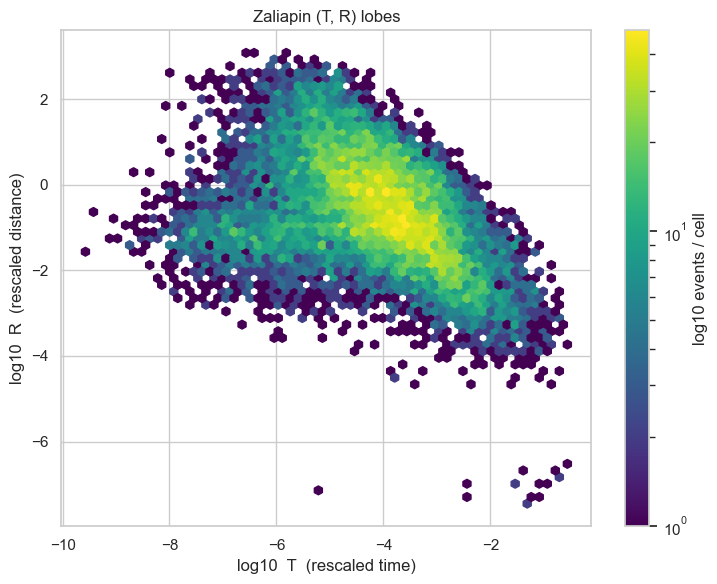

In [6]:
sub = df.dropna(subset=["zaliapin_T", "zaliapin_R"])

fig, ax = plt.subplots(figsize=(7.5, 6))
hb = ax.hexbin(np.log10(sub["zaliapin_T"]), np.log10(sub["zaliapin_R"]),
               gridsize=60, cmap="viridis", mincnt=1, bins="log")
ax.set(xlabel="log10  T  (rescaled time)",
       ylabel="log10  R  (rescaled distance)",
       title="Zaliapin (T, R) lobes")
plt.colorbar(hb, ax=ax, label="log10 events / cell")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_TR_lobes.png", dpi=120, bbox_inches="tight")
plt.show()

## Local activity in (50 km, 30 day) windows

`local_density_30d` and `local_density_7d` count preceding events within 50 km and
the time window. `bath_residual` is the difference between the largest event in the
30-day window and the current event, minus 1.2 — Båth's law predicts the largest
aftershock is ≈ 1.2 magnitudes smaller than its mainshock, so a residual near 0
indicates a Båth-compliant aftershock.

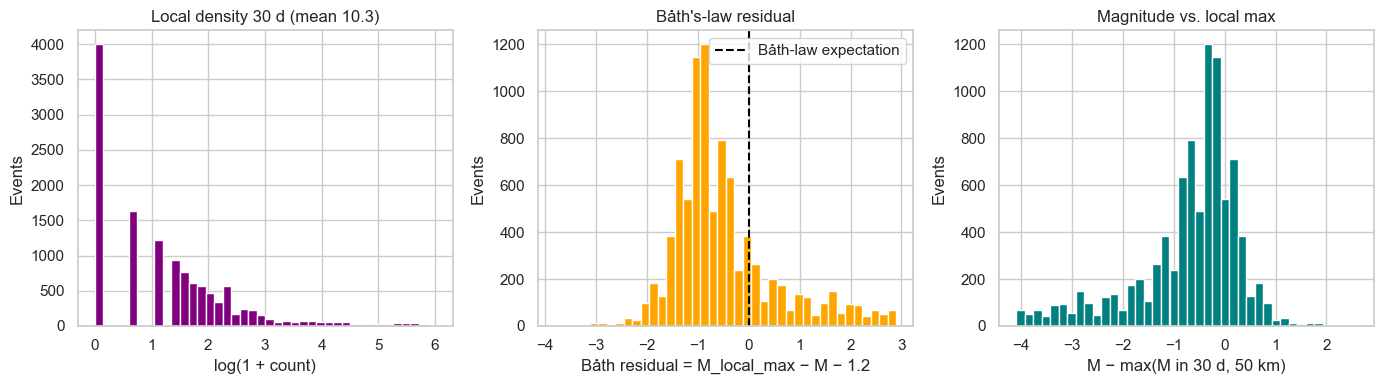

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(np.log1p(df["local_density_30d"]), bins=40, color="purple", edgecolor="white")
axes[0].set(xlabel="log(1 + count)", ylabel="Events",
            title=f"Local density 30 d (mean {df['local_density_30d'].mean():.1f})")

axes[1].hist(df["bath_residual"].dropna(), bins=40, color="orange", edgecolor="white")
axes[1].axvline(0, color="black", ls="--", label="Båth-law expectation")
axes[1].legend()
axes[1].set(xlabel="Båth residual = M_local_max − M − 1.2", ylabel="Events",
            title="Båth's-law residual")

axes[2].hist(df["mag_diff_local_max"].dropna(), bins=40, color="teal", edgecolor="white")
axes[2].set(xlabel="M − max(M in 30 d, 50 km)", ylabel="Events",
            title="Magnitude vs. local max")

plt.tight_layout()
plt.savefig(FIG_DIR / "02_local_activity.png", dpi=120, bbox_inches="tight")
plt.show()

## Case study — Kashmir M7.6, 8 October 2005

This is one of the named verification sequences in the proposal. We slice the
catalog to a 60-day window after the mainshock in the Kashmir region and inspect
how the features behave through the sequence.

485 events in the Kashmir 2005 window  (mainshock M7.6)


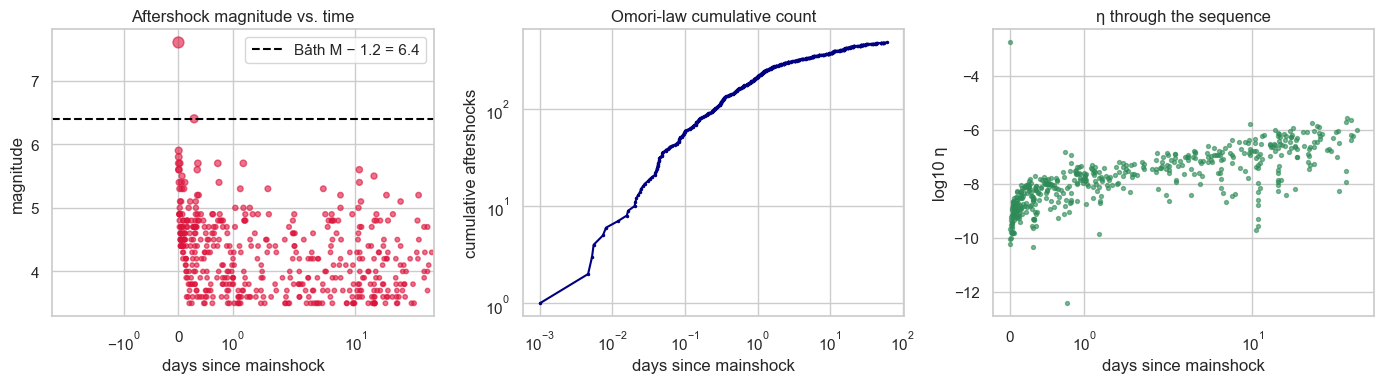

In [8]:
mask = (
    (df["time"] >= "2005-10-08")
    & (df["time"] < "2005-12-08")
    & df["latitude"].between(33.0, 36.0)
    & df["longitude"].between(72.0, 75.0)
)
seq = df[mask].copy()
seq["days_since_main"] = (seq["time"] - seq["time"].iloc[0]).dt.total_seconds() / 86_400
print(f"{len(seq)} events in the Kashmir 2005 window  (mainshock M{seq['mag'].max():.1f})")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(seq["days_since_main"], seq["mag"],
                s=10 + 4 * (seq["mag"] - 4)**2, c="crimson", alpha=0.6)
axes[0].axhline(seq["mag"].max() - 1.2, color="black", ls="--",
                label=f"Båth M − 1.2 = {seq['mag'].max() - 1.2:.1f}")
axes[0].set(xscale="symlog", xlabel="days since mainshock", ylabel="magnitude",
            title="Aftershock magnitude vs. time")
axes[0].legend()

# Omori — cumulative count vs time on log axes; expected slope ≈ 1
axes[1].plot(np.maximum(seq["days_since_main"], 1e-3), np.arange(1, len(seq) + 1),
             color="navy", marker=".", ms=3)
axes[1].set(xscale="log", yscale="log", xlabel="days since mainshock",
            ylabel="cumulative aftershocks", title="Omori-law cumulative count")

axes[2].scatter(seq["days_since_main"], seq["log10_eta"], s=8, c="seagreen", alpha=0.6)
axes[2].set(xscale="symlog", xlabel="days since mainshock",
            ylabel="log10 η", title="η through the sequence")

plt.tight_layout()
plt.savefig(FIG_DIR / "02_kashmir_2005.png", dpi=120, bbox_inches="tight")
plt.show()

## Summary

- **b-value** is in the expected GR range — the catalog above M = 3.5 is consistent with regional seismicity.
- **log10(η) is bimodal**, with a saddle near the literature value (≈ −5 to −7), giving a principled threshold for declustering.
- **Kashmir 2005** sequence is recovered: rapid magnitude decay, Båth-residual ≈ 0 for the largest aftershocks, and η drops by 6+ orders of magnitude within hours of the mainshock.

These features are the inputs to `src.clustering` (DBSCAN / ST-DBSCAN) and `src.classify`
(SVM / Decision Tree / Naive Bayes / KNN) in the next stages.